# Bangkok TMD Rain-Any Station-Only Models (V0)

The **baseline arm** for `TMD_BKK_V1`. V1 reports test ROC-AUC 0.899 at 1 h with 63
features, of which 23 are the precomputed 100 km neighbourhood block, and attributes
~30% of LightGBM split importance to that block. What the block is actually *worth* was
never measured on TMD — the Open-Meteo grid has a controlled ablation
(`bkk_multi_horizon_rain_any_neighbor_features_experiment.ipynb`, +0.016 ROC-AUC at 1 h),
the station network does not. This notebook supplies it.

**One variable changes: the feature list.**

| | V0 (this notebook) | V1 |
|---|---|---|
| station observations | 11 | 11 |
| derived | 13 | 13 |
| lag / rolling | 16 | 16 |
| **neighbourhood 100 km** | **0** | **23** |
| **total features** | **40** | **63** |
| rows, split, hyperparameters, threshold protocol | identical | identical |

## Why the neighbourhood block is still joined and still filtered on

The obvious way to build a station-only model — drop the spatial join entirely — would
**not** be a controlled ablation. V1's `REQUIRED_NON_NULL_COLUMNS` includes
`nearby_precip_mean_lag1_100km`, and it filters `nearby_station_count_100km > 0`. Removing
the join would change which rows survive, and V0 would then differ from V1 in both its
features *and* its training set — the delta would be uninterpretable.

So the pipeline below is byte-identical to V1's: same SQL, same join, same row filter,
same split boundaries. Only `FEATURE_COLUMNS` differs. Section 4c asserts the row count
and split boundaries match V1's saved metadata, and fails loudly if they do not.

**State this limitation when reporting:** V0 is "TMD trained *without* neighbourhood
features, on the rows where neighbourhood features exist." It is not "TMD with no spatial
data available at all" — that model would see a larger and differently-shaped row set.

## 1. Setup

In [1]:
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

Every value here is copied from `TMD_BKK_V1` unchanged except `MODEL_DIR` and
`FEATURE_SET_NAME`.

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"BKK_TMD_WEATHER_DATA"'
SPATIAL_TABLE_NAME = '"BKK_TMD_SPATIAL_FEATURES_100KM"'
KEEP_REGION = "1"  # region 2 has 2 stations / 871 rows and no spatial-feature coverage

PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "tmd_bkk_rain_any_v0_station_only"
V1_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "tmd_bkk_rain_any_final_4_neighbor_models"

FEATURE_SET_NAME = "tmd_station_only"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

# Operating thresholds carried over from the Bangkok Open-Meteo notebook, comparison only.
BANGKOK_PROBABILITY_THRESHOLDS = {
    1: 0.60,
    2: 0.50,
    3: 0.30,
    6: 0.30,
}
MODEL_PLAN = {
    1: "lightgbm",
    2: "lightgbm",
    3: "hist_gradient_boosting",
    6: "hist_gradient_boosting",
}

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_STATIONS = None
RANDOM_STATE = 42

## 3. Feature Columns

All four blocks are declared exactly as in V1 so the data pipeline and the row filter are
unchanged. `FEATURE_COLUMNS` then omits `NEIGHBOR_FEATURE_COLUMNS` — this line is the
entire experiment.

In [3]:
# --- station observations, as reported by TMD ---------------------------------
STATION_FEATURE_COLUMNS = [
    "latitude", "longitude", "altitude_m",
    "temperature_c", "precipitation_mm", "pressure_hpa", "humidity_percent",
    "wind_speed_avg_knot", "max_wind_speed_knot",
    # ~32% null; passed through as NaN because both learners split on NaN natively.
    "weather_code", "visibility_m",
]

# --- derived in section 4 -----------------------------------------------------
DERIVED_FEATURE_COLUMNS = [
    "wind_dir_avg_sin", "wind_dir_avg_cos", "max_wind_dir_sin", "max_wind_dir_cos",
    "temperature_humidity_index", "temperature_dew_point_spread_est",
    "pressure_hpa_change_3h", "pressure_hpa_change_6h", "humidity_change_3h",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]

LAG_FEATURE_COLUMNS = [
    "precipitation_lag_1h", "precipitation_lag_2h", "precipitation_lag_3h", "precipitation_lag_6h",
    "precipitation_sum_past_3h", "precipitation_sum_past_6h",
    "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "temperature_lag_1h", "temperature_lag_3h",
    "humidity_lag_1h", "humidity_lag_3h",
    "pressure_lag_1h", "pressure_lag_3h",
    "wind_speed_lag_1h", "wind_speed_lag_3h",
]

# --- precomputed 100 km neighbourhood block ------------------------------------
# Still SELECTed and still used by the row filter, but NOT given to the model.
SPATIAL_TABLE_COLUMNS = [
    "nearest_station_distance_km",
    "nearby_station_count_50km", "nearby_station_count_100km", "nearby_station_count_200km",
    "nearby_precip_mean_now_100km", "nearby_precip_max_now_100km",
    "nearby_rain_rate_now_010mm_100km", "nearby_rain_rate_now_025mm_100km",
    "nearby_humidity_mean_now_100km", "nearby_pressure_mean_now_100km",
    "nearby_wind_speed_mean_now_100km",
    "nearby_precip_mean_lag1_100km", "nearby_precip_max_lag1_100km",
    "nearby_rain_rate_lag1_010mm_100km", "nearby_rain_rate_lag1_025mm_100km",
    "nearby_humidity_mean_lag1_100km", "nearby_pressure_mean_lag1_100km",
    "nearby_wind_speed_mean_lag1_100km",
    "nearest_rainy_station_distance_lag1_010mm_km",
    "nearest_rainy_station_distance_lag1_025mm_km",
]

NEIGHBOR_CONTRAST_COLUMNS = [
    "nearby_precip_mean_now_minus_center",
    "nearby_humidity_mean_now_minus_center",
    "center_pressure_minus_nearby_mean",
]

NEIGHBOR_FEATURE_COLUMNS = SPATIAL_TABLE_COLUMNS + NEIGHBOR_CONTRAST_COLUMNS

# >>> THE ONLY LINE THAT DIFFERS FROM V1 <<<
FEATURE_COLUMNS = (
    STATION_FEATURE_COLUMNS + DERIVED_FEATURE_COLUMNS + LAG_FEATURE_COLUMNS
)

TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]

# Unchanged from V1 - including the neighbourhood member, so the surviving row set is
# identical. See the header note on why this is deliberate.
REQUIRED_NON_NULL_COLUMNS = [
    "temperature_c", "precipitation_mm", "pressure_hpa", "humidity_percent",
    "pressure_hpa_change_6h", "precipitation_lag_6h", "precipitation_sum_past_24h",
    "humidity_lag_3h", "wind_speed_lag_3h", "nearby_precip_mean_lag1_100km",
    f"rain_any_next_{max(HORIZONS)}h",
]

assert not set(FEATURE_COLUMNS) & set(NEIGHBOR_FEATURE_COLUMNS), \
    "V0 must not contain any neighbourhood feature"

print(f"Features used: {len(FEATURE_COLUMNS)}   (V1 used 63)")
print(f"  station observations : {len(STATION_FEATURE_COLUMNS)}")
print(f"  derived              : {len(DERIVED_FEATURE_COLUMNS)}")
print(f"  lag / rolling        : {len(LAG_FEATURE_COLUMNS)}")
print(f"  neighbourhood 100 km : 0  (withheld; {len(NEIGHBOR_FEATURE_COLUMNS)} available)")
print(f"Targets: {TARGET_COLUMNS}")

Features used: 40   (V1 used 63)
  station observations : 11
  derived              : 13
  lag / rolling        : 16
  neighbourhood 100 km : 0  (withheld; 23 available)
Targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load And Engineer TMD Training Data

Verbatim from V1. The spatial join stays so the row filter behaves identically.

In [4]:
def connect():
    return psycopg2.connect(**DB_CONFIG)


def read_raw_tmd_data(sample_stations=None):
    """Observations LEFT JOINed to their precomputed 100 km neighbourhood features."""
    neighbor_sql = ",\n        ".join(f"spatial.{c}" for c in SPATIAL_TABLE_COLUMNS)
    query = f"""
    SELECT
        weather.utc_time,
        weather.station,
        weather.station_name,
        weather.latitude,
        weather.longitude,
        weather.altitude_m,
        weather.wind_dir_avg_deg,
        weather.max_wind_dir_deg,
        weather.wind_speed_avg_knot,
        weather.max_wind_speed_knot,
        weather.temperature_c,
        -- 62 rows carry sentinel values down to -3174 mm. NULL them rather than clip to 0.
        CASE WHEN weather.precipitation_mm >= 0 THEN weather.precipitation_mm END AS precipitation_mm,
        weather.pressure_hpa,
        weather.humidity_percent,
        weather.weather_code,
        weather.visibility_m,
        {neighbor_sql}
    FROM {TABLE_NAME} weather
    LEFT JOIN {SPATIAL_TABLE_NAME} spatial
      ON spatial.station = weather.station
     AND spatial.utc_time = weather.utc_time
    WHERE weather.utc_time IS NOT NULL
      AND weather.station IS NOT NULL
      AND weather.latitude IS NOT NULL
      AND weather.longitude IS NOT NULL
      AND weather.region = %(region)s
    ORDER BY weather.station, weather.utc_time
    """
    with connect() as conn:
        raw = pd.read_sql_query(query, conn, params={"region": KEEP_REGION},
                                parse_dates=["utc_time"])
    if sample_stations:
        keep = sorted(raw["station"].unique())[:sample_stations]
        raw = raw[raw["station"].isin(keep)].reset_index(drop=True)
    return raw


def to_hourly_panel(raw):
    """Reindex each station onto a gap-free hourly DatetimeIndex."""
    static_columns = ["station_name", "latitude", "longitude", "altitude_m"]
    frames = []
    for station_id, group in raw.groupby("station", sort=True):
        group = group.drop_duplicates("utc_time").set_index("utc_time").sort_index()
        full_index = pd.date_range(group.index.min(), group.index.max(), freq="h")
        group = group.reindex(full_index)
        group.index.name = "forecast_time"
        group["station"] = station_id
        group[static_columns] = group[static_columns].ffill().bfill()
        frames.append(group.reset_index())
    return pd.concat(frames, ignore_index=True)


def angular_sin(series):
    return np.sin(np.deg2rad(series.astype("float64")))


def angular_cos(series):
    return np.cos(np.deg2rad(series.astype("float64")))


def estimate_dew_point_c(temperature_c, humidity_percent):
    """Magnus-Tetens dew point. TMD does not report dew point directly."""
    humidity = humidity_percent.clip(lower=1, upper=100)
    alpha = np.log(humidity / 100.0) + (17.625 * temperature_c) / (243.04 + temperature_c)
    return (243.04 * alpha) / (17.625 - alpha)


def add_derived_features(data):
    data["wind_dir_avg_sin"] = angular_sin(data["wind_dir_avg_deg"])
    data["wind_dir_avg_cos"] = angular_cos(data["wind_dir_avg_deg"])
    data["max_wind_dir_sin"] = angular_sin(data["max_wind_dir_deg"])
    data["max_wind_dir_cos"] = angular_cos(data["max_wind_dir_deg"])
    data["temperature_humidity_index"] = data["temperature_c"] * (data["humidity_percent"] / 100.0)
    dew_point = estimate_dew_point_c(data["temperature_c"], data["humidity_percent"])
    data["temperature_dew_point_spread_est"] = data["temperature_c"] - dew_point

    hour = data["forecast_time"].dt.hour
    month = data["forecast_time"].dt.month
    data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    data["month_sin"] = np.sin(2 * np.pi * month / 12)
    data["month_cos"] = np.cos(2 * np.pi * month / 12)

    # Computed but not used as features in V0 - kept so the pipeline matches V1 exactly.
    data["nearby_precip_mean_now_minus_center"] = (
        data["nearby_precip_mean_now_100km"] - data["precipitation_mm"])
    data["nearby_humidity_mean_now_minus_center"] = (
        data["nearby_humidity_mean_now_100km"] - data["humidity_percent"])
    data["center_pressure_minus_nearby_mean"] = (
        data["pressure_hpa"] - data["nearby_pressure_mean_now_100km"])
    return data


def add_lag_features(data):
    """Backward-looking features. Shifting by rows is safe because the panel is gap-free."""
    grouped = data.groupby("station", group_keys=False)

    data["pressure_hpa_change_3h"] = grouped["pressure_hpa"].diff(3)
    data["pressure_hpa_change_6h"] = grouped["pressure_hpa"].diff(6)
    data["humidity_change_3h"] = grouped["humidity_percent"].diff(3)

    lag_specs = {
        "precipitation_lag_1h": ("precipitation_mm", 1),
        "precipitation_lag_2h": ("precipitation_mm", 2),
        "precipitation_lag_3h": ("precipitation_mm", 3),
        "precipitation_lag_6h": ("precipitation_mm", 6),
        "temperature_lag_1h": ("temperature_c", 1),
        "temperature_lag_3h": ("temperature_c", 3),
        "humidity_lag_1h": ("humidity_percent", 1),
        "humidity_lag_3h": ("humidity_percent", 3),
        "pressure_lag_1h": ("pressure_hpa", 1),
        "pressure_lag_3h": ("pressure_hpa", 3),
        "wind_speed_lag_1h": ("wind_speed_avg_knot", 1),
        "wind_speed_lag_3h": ("wind_speed_avg_knot", 3),
    }
    for output_column, (source_column, lag) in lag_specs.items():
        data[output_column] = grouped[source_column].shift(lag)

    for hours in [3, 6, 12, 24]:
        data[f"precipitation_sum_past_{hours}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=hours: s.shift(1).rolling(window, min_periods=window).sum()
        )
    return data


def add_targets(data):
    """rain_any_next_Nh: did the station gauge record >= RAIN_THRESHOLD_MM in any of the
    next N hours. NaN whenever any hour of that window is unobserved."""

    def future_rain_any(series, window):
        future_max = (
            series.shift(-1).rolling(window, min_periods=window).max().shift(-(window - 1))
        )
        return pd.Series(
            np.where(future_max.notna(), (future_max >= RAIN_THRESHOLD_MM).astype("float"), np.nan),
            index=series.index,
        )

    grouped = data.groupby("station", group_keys=False)
    for horizon in HORIZONS:
        data[f"rain_any_next_{horizon}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=horizon: future_rain_any(s, window)
        )
    return data


def read_training_data(sample_stations=None):
    raw = read_raw_tmd_data(sample_stations)
    print(f"raw observations : {len(raw):,} rows, {raw['station'].nunique()} stations")

    panel = to_hourly_panel(raw)
    inserted = len(panel) - len(raw)
    print(f"hourly panel     : {len(panel):,} rows "
          f"({inserted:,} NaN spacers inserted for missing hours, "
          f"{inserted / len(panel):.1%} of the grid)")

    panel = add_derived_features(panel)
    panel = add_lag_features(panel)
    panel = add_targets(panel)

    complete = panel.dropna(subset=REQUIRED_NON_NULL_COLUMNS).copy()
    complete = complete[complete["nearby_station_count_100km"] > 0]
    complete[TARGET_COLUMNS] = complete[TARGET_COLUMNS].astype("int8")
    complete = complete.sort_values(["forecast_time", "station"]).reset_index(drop=True)
    print(f"modelling rows   : {len(complete):,} "
          f"({len(complete) / len(panel):.1%} of the hourly grid survive the non-null filter)")
    return complete, panel

In [5]:
model_df, hourly_panel = read_training_data(SAMPLE_STATIONS)

x_all = np.ascontiguousarray(model_df[FEATURE_COLUMNS].to_numpy(dtype="float32"))
y_all = model_df[TARGET_COLUMNS].to_numpy(dtype="int8")
forecast_time = model_df["forecast_time"].to_numpy(dtype="datetime64[s]")
station = model_df["station"].to_numpy()

print(f"\nx: {x_all.shape}  y: {y_all.shape}")
print(f"{forecast_time.min()} to {forecast_time.max()}")
print(f"stations: {np.unique(station).size}")
print(f"x memory: {x_all.nbytes / 1e9:.2f} GB")

nan_counts = np.isnan(x_all).sum(axis=0)
if nan_counts.any():
    print("\nRemaining NaNs (passed to the model as-is):")
    display(pd.Series(nan_counts, index=FEATURE_COLUMNS)
            .loc[lambda s: s > 0].sort_values(ascending=False)
            .to_frame("nan_rows").assign(nan_share=lambda d: d["nan_rows"] / len(x_all)))
else:
    print("No NaNs in feature matrix.")

C:\Users\Brandon\AppData\Local\Temp\ipykernel_27156\2694091233.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw = pd.read_sql_query(query, conn, params={"region": KEEP_REGION},


raw observations : 1,005,080 rows, 26 stations


hourly panel     : 1,225,594 rows (220,514 NaN spacers inserted for missing hours, 18.0% of the grid)


modelling rows   : 902,356 (73.6% of the hourly grid survive the non-null filter)



x: (902356, 40)  y: (902356, 4)
2020-01-02T01:00:00 to 2026-06-24T03:00:00


stations: 26
x memory: 0.14 GB

Remaining NaNs (passed to the model as-is):


,nan_rows,nan_share
visibility_m,285475,0.3164
weather_code,284379,0.3152
max_wind_dir_sin,2830,0.0031
max_wind_dir_cos,2830,0.0031
wind_dir_avg_sin,2720,0.0030
wind_dir_avg_cos,2720,0.0030
humidity_lag_1h,379,0.0004
max_wind_speed_knot,261,0.0003
wind_speed_avg_knot,218,0.0002
wind_speed_lag_1h,190,0.0002


### 4b. Panel Sanity Checks

Carried over from V1: every lag must be a true clock lag, and the label must agree with a
direct recompute off the raw gauge.

In [6]:
check = model_df.sort_values(["station", "forecast_time"])
hours_since_previous = (
    check.groupby("station")["forecast_time"].diff().dt.total_seconds() / 3600
)
breaks = int((hours_since_previous.dropna() != 1).sum())
print(f"lag integrity: {breaks:,} surviving rows sit just after an outage gap.")

first_station = check["station"].iloc[0]
gauge = (
    hourly_panel[hourly_panel["station"] == first_station]
    .set_index("forecast_time")["precipitation_mm"]
    .sort_index()
)
recomputed = (
    gauge.shift(-1).rolling(3, min_periods=3).max().shift(-2) >= RAIN_THRESHOLD_MM
).astype("float")

spot = check[check["station"] == first_station].set_index("forecast_time")
aligned = recomputed.reindex(spot.index)
agreement = (aligned == spot["rain_any_next_3h"]).mean()
print(f"label check (station {first_station}): rain_any_next_3h matches a direct recompute "
      f"off the raw gauge on {agreement:.4%} of {len(spot):,} rows")

lag integrity: 3,183 surviving rows sit just after an outage gap.
label check (station 1030): rain_any_next_3h matches a direct recompute off the raw gauge on 100.0000% of 19,363 rows


### 4c. Row-Identity Check Against V1

The ablation is only interpretable if V0 and V1 trained on the same rows. This asserts it
against V1's saved metadata rather than trusting that the pipeline was copied correctly.

In [7]:
V1_META = json.loads((V1_DIR / "final_4_metadata.json").read_text(encoding="utf-8"))

identity = pd.DataFrame([
    {"quantity": "modelling rows", "V0": int(x_all.shape[0]), "V1": int(V1_META["rows"])},
    {"quantity": "stations", "V0": int(np.unique(station).size), "V1": int(V1_META["stations"])},
])
identity["match"] = identity["V0"] == identity["V1"]
display(identity)

print(f"V0 feature count {len(FEATURE_COLUMNS)} vs V1 {len(V1_META['feature_columns'])}")
withheld = sorted(set(V1_META["feature_columns"]) - set(FEATURE_COLUMNS))
print(f"withheld from V0 ({len(withheld)}): {withheld}")
assert set(FEATURE_COLUMNS) < set(V1_META["feature_columns"]), \
    "V0 features must be a strict subset of V1's"
assert bool(identity["match"].all()), "row set diverged from V1 - ablation is confounded"
print("\nrow set matches V1; feature list is a strict subset. Ablation is controlled.")

,quantity,V0,V1,match
0,modelling rows,902356,902356,True
1,stations,26,26,True


V0 feature count 40 vs V1 63
withheld from V0 (23): ['center_pressure_minus_nearby_mean', 'nearby_humidity_mean_lag1_100km', 'nearby_humidity_mean_now_100km', 'nearby_humidity_mean_now_minus_center', 'nearby_precip_max_lag1_100km', 'nearby_precip_max_now_100km', 'nearby_precip_mean_lag1_100km', 'nearby_precip_mean_now_100km', 'nearby_precip_mean_now_minus_center', 'nearby_pressure_mean_lag1_100km', 'nearby_pressure_mean_now_100km', 'nearby_rain_rate_lag1_010mm_100km', 'nearby_rain_rate_lag1_025mm_100km', 'nearby_rain_rate_now_010mm_100km', 'nearby_rain_rate_now_025mm_100km', 'nearby_station_count_100km', 'nearby_station_count_200km', 'nearby_station_count_50km', 'nearby_wind_speed_mean_lag1_100km', 'nearby_wind_speed_mean_now_100km', 'nearest_rainy_station_distance_lag1_010mm_km', 'nearest_rainy_station_distance_lag1_025mm_km', 'nearest_station_distance_km']

row set matches V1; feature list is a strict subset. Ablation is controlled.


## 5. Target Balance

In [8]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": int(y_all.shape[0]),
        "rain_rows": int(y_all[:, i].sum()),
        "rain_rate": float(y_all[:, i].mean()),
    }
    for i, horizon in enumerate(HORIZONS)
])
display(target_balance)

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1000,902356,46536,0.0516
1,2,rain_any_next_2h,0.1000,902356,67764,0.0751
2,3,rain_any_next_3h,0.1000,902356,85591,0.0949
3,6,rain_any_next_6h,0.1000,902356,129948,0.1440


## 6. Chronological Split

In [9]:
def time_split_bounds(times, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.unique(times)
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    train_stop = int(np.searchsorted(times, train_end, side="left"))
    validation_stop = int(np.searchsorted(times, validation_end, side="left"))
    return train_end, validation_end, train_stop, validation_stop


train_end, validation_end, train_stop, validation_stop = time_split_bounds(
    forecast_time, TRAIN_FRACTION, VALIDATION_FRACTION
)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")
print(f"V1 train before: {V1_META['train_end_exclusive']}")
print(f"V1 validation before: {V1_META['validation_end_exclusive']}")
assert str(train_end) == V1_META["train_end_exclusive"], "split boundary diverged from V1"
assert str(validation_end) == V1_META["validation_end_exclusive"], "split boundary diverged from V1"

x_train, x_validation, x_test = x_all[:train_stop], x_all[train_stop:validation_stop], x_all[validation_stop:]
y_train_all, y_validation_all, y_test_all = y_all[:train_stop], y_all[train_stop:validation_stop], y_all[validation_stop:]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(x_train), "stations": np.unique(station[:train_stop]).size,
     "from": str(forecast_time[:train_stop].min()), "to": str(forecast_time[:train_stop].max())},
    {"split": "validation", "rows": len(x_validation),
     "stations": np.unique(station[train_stop:validation_stop]).size,
     "from": str(forecast_time[train_stop:validation_stop].min()),
     "to": str(forecast_time[train_stop:validation_stop].max())},
    {"split": "test", "rows": len(x_test), "stations": np.unique(station[validation_stop:]).size,
     "from": str(forecast_time[validation_stop:].min()), "to": str(forecast_time[validation_stop:].max())},
])
display(split_summary)
print(f"splits are zero-copy views: {x_train.base is x_all and x_test.base is x_all}")

Train before: 2024-05-26T19:00:00
Validation before: 2025-03-29T20:00:00
V1 train before: 2024-05-26T19:00:00
V1 validation before: 2025-03-29T20:00:00


,split,rows,stations,from,to
0,train,556560,26,2020-01-02T01:00:00,2024-05-26T18:00:00
1,validation,174206,26,2024-05-26T19:00:00,2025-03-29T19:00:00
2,test,171590,26,2025-03-29T20:00:00,2026-06-24T03:00:00


splits are zero-copy views: True


## 7. Evaluation Helpers

In [10]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "feature_set": FEATURE_SET_NAME,
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )


def metrics_at_thresholds(threshold_results, chosen_thresholds, split="test"):
    rows = []
    for horizon, threshold in chosen_thresholds.items():
        selected = threshold_results[
            (threshold_results["horizon_h"] == horizon)
            & (threshold_results["model"] == MODEL_PLAN[horizon])
            & (threshold_results["split"] == split)
            & (threshold_results["probability_threshold"].round(10) == round(threshold, 10))
        ]
        rows.append(selected)
    return pd.concat(rows, ignore_index=True)

## 8. Train The Four Models

Hyperparameters identical to V1, down to `random_state`.

In [11]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

models = {}
metric_rows = []
threshold_tables = []
feature_importance_rows = []
train_timings = {}

for index, horizon in enumerate(HORIZONS):
    model_name = MODEL_PLAN[horizon]
    target = f"rain_any_next_{horizon}h"
    print(f"Training {model_name} for {target}...", flush=True)
    started = time.time()

    y_train = y_train_all[:, index]
    y_validation = y_validation_all[:, index]
    y_test = y_test_all[:, index]

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(
            x_train,
            y_train,
            eval_X=x_validation,
            eval_y=y_validation,
            eval_metric="binary_logloss",
        )
        for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
            feature_importance_rows.append({
                "model": model_name,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
            })
    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
            early_stopping=False,
        )
        model.fit(x_train, y_train)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    models[horizon] = model
    train_timings[horizon] = time.time() - started
    print(f"  fitted in {train_timings[horizon] / 60:.1f} min", flush=True)

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(y_split, probabilities, model_name, horizon, split_name)
        metric_rows.append(metrics)
        threshold_tables.append(thresholds)

all_metrics = pd.DataFrame(metric_rows)
all_threshold_results = pd.concat(threshold_tables, ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)

display(all_metrics.sort_values(["horizon_h", "split"]))

Training lightgbm for rain_any_next_1h...


  fitted in 0.2 min


Training lightgbm for rain_any_next_2h...


  fitted in 0.2 min


Training hist_gradient_boosting for rain_any_next_3h...


  fitted in 0.2 min


Training hist_gradient_boosting for rain_any_next_6h...


  fitted in 0.1 min


,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,tmd_station_only,1,test,171590,0.0734,0.8833,0.5562,0.1352
0,lightgbm,tmd_station_only,1,validation,174206,0.0523,0.9254,0.5771,0.1000
3,lightgbm,tmd_station_only,2,test,171590,0.1075,0.8489,0.5396,0.1666
2,lightgbm,tmd_station_only,2,validation,174206,0.0762,0.9045,0.5674,0.1235
5,hist_gradient_boosting,tmd_station_only,3,test,171590,0.1364,0.8279,0.5388,0.0873
4,hist_gradient_boosting,tmd_station_only,3,validation,174206,0.0959,0.8929,0.5707,0.0588
7,hist_gradient_boosting,tmd_station_only,6,test,171590,0.2084,0.7996,0.5676,0.1277
6,hist_gradient_boosting,tmd_station_only,6,validation,174206,0.1447,0.8772,0.6001,0.0848


## 8b. Operating Threshold Selection

Picked on validation by best F1, applied once to test. Same protocol as V1.

In [12]:
validation_best = best_by_f1[best_by_f1["split"] == "validation"]
SELECTED_PROBABILITY_THRESHOLDS = {
    int(row.horizon_h): float(row.probability_threshold)
    for row in validation_best.itertuples()
}
print("V0 selected on validation:", SELECTED_PROBABILITY_THRESHOLDS)
print("V1 selected on validation:", V1_META["selected_probability_thresholds"])

selected_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, SELECTED_PROBABILITY_THRESHOLDS, split="test")

report_columns = [
    "horizon_h", "model", "probability_threshold", "rain_rate", "predicted_rain_rate",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier_score",
    "true_positives", "false_positives", "false_negatives", "true_negatives",
]

print("\nTEST metrics at validation-selected thresholds")
display(selected_threshold_metrics[report_columns].sort_values("horizon_h"))

V0 selected on validation: {3: 0.30000000000000004, 6: 0.25000000000000006, 1: 0.8500000000000002, 2: 0.8000000000000002}
V1 selected on validation: {'3': 0.30000000000000004, '6': 0.30000000000000004, '1': 0.8500000000000002, '2': 0.8000000000000002}

TEST metrics at validation-selected thresholds


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
2,1,lightgbm,0.8500,0.0734,0.0677,0.9364,0.5724,0.5280,0.5493,0.8833,0.5562,0.1352,6647,4965,5941,154037
3,2,lightgbm,0.8000,0.1075,0.0970,0.9001,0.5394,0.4868,0.5118,0.8489,0.5396,0.1666,8980,7667,9468,145475
0,3,hist_gradient_boosting,0.3000,0.1364,0.1035,0.8781,0.5703,0.4326,0.4920,0.8279,0.5388,0.0873,10125,7630,13279,140556
1,6,hist_gradient_boosting,0.2500,0.2084,0.2570,0.7759,0.4694,0.5789,0.5185,0.7996,0.5676,0.1277,20700,23395,15056,112439


## 9. The Ablation — V0 versus V1

Ranking metrics (ROC-AUC, PR-AUC) are threshold-free, so they compare directly. Brier
skill is reported against each horizon's own climatology so it is comparable across the
differing base rates.

In [13]:
v1_metrics = pd.read_csv(V1_DIR / "final_4_metrics.csv")

v0_test = all_metrics[all_metrics["split"] == "test"].set_index("horizon_h")
v1_test = v1_metrics[v1_metrics["split"] == "test"].set_index("horizon_h")

ablation = pd.DataFrame({
    "model": v0_test["model"],
    "base_rate": v0_test["rain_rate"],
    "roc_auc_V0": v0_test["roc_auc"],
    "roc_auc_V1": v1_test["roc_auc"],
    "pr_auc_V0": v0_test["pr_auc"],
    "pr_auc_V1": v1_test["pr_auc"],
    "brier_V0": v0_test["brier_score"],
    "brier_V1": v1_test["brier_score"],
})
ablation["roc_auc_delta"] = ablation["roc_auc_V1"] - ablation["roc_auc_V0"]
ablation["pr_auc_delta"] = ablation["pr_auc_V1"] - ablation["pr_auc_V0"]
ablation["brier_delta"] = ablation["brier_V1"] - ablation["brier_V0"]

# Lift and Brier skill: base-rate independent, so comparable across horizons.
ablation["lift_V0"] = ablation["pr_auc_V0"] / ablation["base_rate"]
ablation["lift_V1"] = ablation["pr_auc_V1"] / ablation["base_rate"]
climatology = ablation["base_rate"] * (1 - ablation["base_rate"])
ablation["brier_skill_V0"] = 1 - ablation["brier_V0"] / climatology
ablation["brier_skill_V1"] = 1 - ablation["brier_V1"] / climatology

print("=== TMD neighbourhood-feature ablation, test split ===")
display(ablation[["model", "base_rate", "roc_auc_V0", "roc_auc_V1", "roc_auc_delta",
                  "pr_auc_V0", "pr_auc_V1", "pr_auc_delta"]].round(4))

print("\n=== base-rate-independent view ===")
display(ablation[["lift_V0", "lift_V1", "brier_skill_V0", "brier_skill_V1"]].round(4))

print("\nReference - the Open-Meteo grid ablation (same experiment, 36 vs 66 features):")
print("  1h +0.0160   2h +0.0127   3h +0.0093   6h +0.0049   ROC-AUC")

=== TMD neighbourhood-feature ablation, test split ===


,model,base_rate,roc_auc_V0,roc_auc_V1,roc_auc_delta,pr_auc_V0,pr_auc_V1,pr_auc_delta
horizon_h,,,,,,,,
1,lightgbm,0.0734,0.8833,0.8988,0.0155,0.5562,0.5787,0.0225
2,lightgbm,0.1075,0.8489,0.8691,0.0202,0.5396,0.5689,0.0293
3,hist_gradient_boosting,0.1364,0.8279,0.8486,0.0207,0.5388,0.5703,0.0315
6,hist_gradient_boosting,0.2084,0.7996,0.8156,0.0159,0.5676,0.5912,0.0236



=== base-rate-independent view ===


,lift_V0,lift_V1,brier_skill_V0,brier_skill_V1
horizon_h,,,,
1,7.5813,7.8880,-0.9894,-0.8320
2,5.0191,5.2914,-0.7358,-0.6255
3,3.9501,4.1812,0.2592,0.2879
6,2.7240,2.8372,0.2259,0.2498



Reference - the Open-Meteo grid ablation (same experiment, 36 vs 66 features):
  1h +0.0160   2h +0.0127   3h +0.0093   6h +0.0049   ROC-AUC


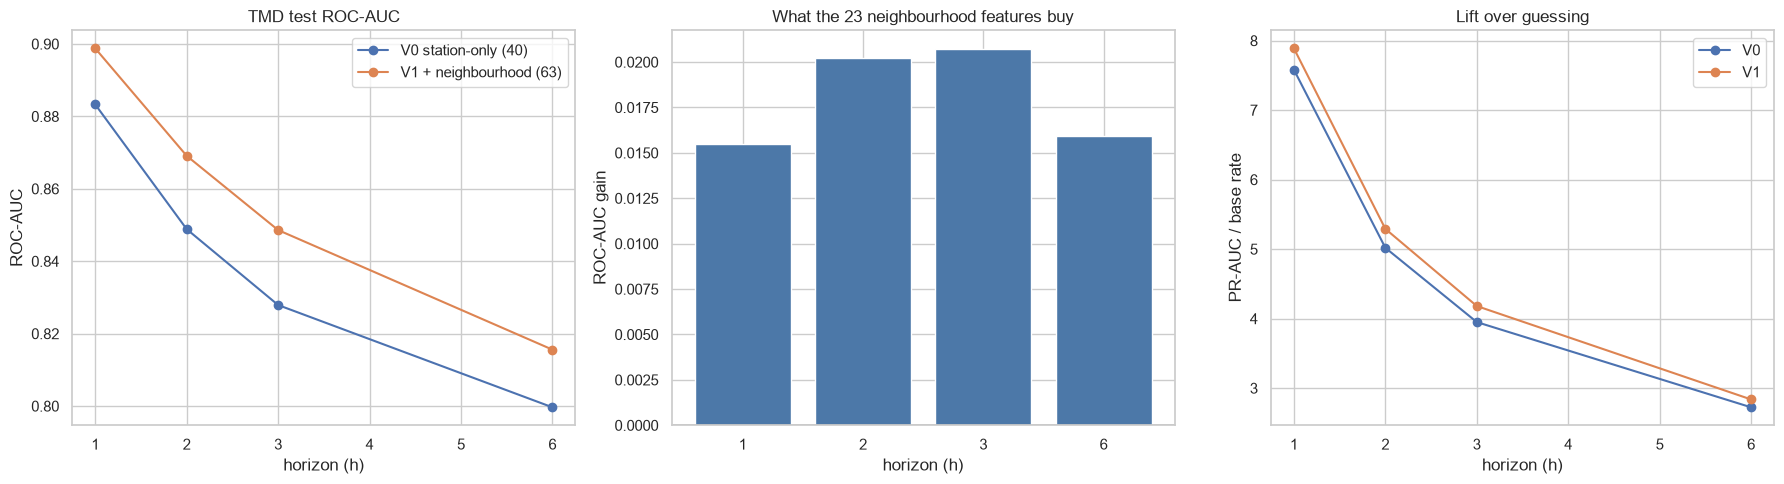

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(ablation.index, ablation["roc_auc_V0"], marker="o", label="V0 station-only (40)")
ax.plot(ablation.index, ablation["roc_auc_V1"], marker="o", label="V1 + neighbourhood (63)")
ax.set_xlabel("horizon (h)"); ax.set_ylabel("ROC-AUC")
ax.set_title("TMD test ROC-AUC"); ax.legend()

ax = axes[1]
ax.bar(ablation.index.astype(str), ablation["roc_auc_delta"], color="#4c78a8")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("horizon (h)"); ax.set_ylabel("ROC-AUC gain")
ax.set_title("What the 23 neighbourhood features buy")

ax = axes[2]
ax.plot(ablation.index, ablation["lift_V0"], marker="o", label="V0")
ax.plot(ablation.index, ablation["lift_V1"], marker="o", label="V1")
ax.set_xlabel("horizon (h)"); ax.set_ylabel("PR-AUC / base rate")
ax.set_title("Lift over guessing"); ax.legend()

plt.tight_layout()
plt.show()

## 10. Feature Importance (station-only)

,model,horizon_h,feature,importance
8,lightgbm,1,max_wind_speed_knot,1406.0000
17,lightgbm,1,pressure_hpa_change_3h,1395.0000
15,lightgbm,1,temperature_humidity_index,1345.0000
18,lightgbm,1,pressure_hpa_change_6h,1332.0000
7,lightgbm,1,wind_speed_avg_knot,1310.0000
19,lightgbm,1,humidity_change_3h,1303.0000
3,lightgbm,1,temperature_c,1292.0000
12,lightgbm,1,wind_dir_avg_cos,1209.0000
11,lightgbm,1,wind_dir_avg_sin,1191.0000
38,lightgbm,1,wind_speed_lag_1h,1173.0000


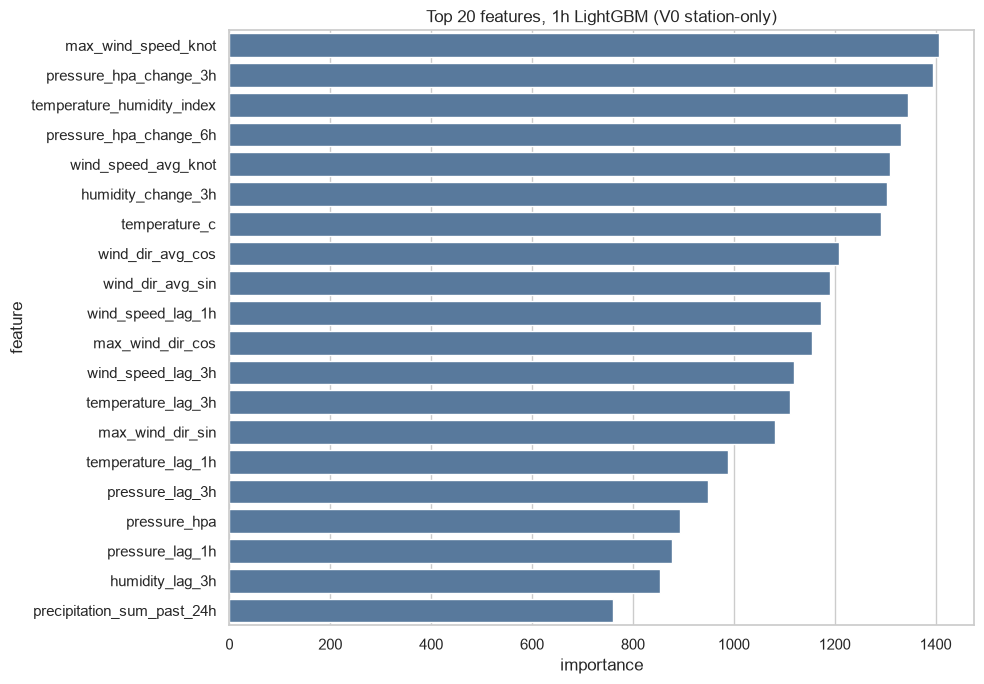

In [15]:
feature_importance = pd.DataFrame(feature_importance_rows)
if not feature_importance.empty:
    top_importance = (
        feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False])
        .groupby("horizon_h").head(15)
    )
    display(top_importance)

    fig, ax = plt.subplots(figsize=(10, 7))
    top_1h = feature_importance[feature_importance["horizon_h"] == 1].nlargest(20, "importance")
    sns.barplot(data=top_1h, y="feature", x="importance", color="#4c78a8", ax=ax)
    ax.set_title("Top 20 features, 1h LightGBM (V0 station-only)")
    plt.tight_layout()
    plt.show()

## 11. Save

In [16]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    model_name = MODEL_PLAN[horizon]
    threshold = SELECTED_PROBABILITY_THRESHOLDS[horizon]
    path = MODEL_DIR / (
        f"tmd_bkk_rain_any_v0_next_{horizon}h_station_only_{model_name}"
        f"_prob_threshold_{threshold:g}_rain_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    )
    joblib.dump(model, path)

target_balance.to_csv(MODEL_DIR / "v0_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "v0_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "v0_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "v0_best_thresholds_by_f1.csv", index=False)
selected_threshold_metrics.to_csv(MODEL_DIR / "v0_selected_threshold_metrics.csv", index=False)
ablation.to_csv(MODEL_DIR / "v0_vs_v1_ablation.csv")
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "v0_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "spatial_table": SPATIAL_TABLE_NAME,
    "feature_set": FEATURE_SET_NAME,
    "role": "baseline (station-only) arm of the TMD neighbourhood-feature ablation",
    "compared_against": str(V1_DIR),
    "region_filter": KEEP_REGION,
    "model_plan": MODEL_PLAN,
    "selected_probability_thresholds": SELECTED_PROBABILITY_THRESHOLDS,
    "threshold_selection": "best F1 on validation split, evaluated once on test",
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "withheld_neighbor_columns": NEIGHBOR_FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "required_non_null_columns": REQUIRED_NON_NULL_COLUMNS,
    "controlled_ablation_note": (
        "the 100 km spatial block is still joined and still used by the row filter, so V0 "
        "and V1 train on identical rows; only FEATURE_COLUMNS differs. V0 is therefore "
        "'TMD without neighbourhood features on the rows where they exist', not 'TMD with "
        "no spatial data available'."
    ),
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "rows": int(x_all.shape[0]),
    "stations": int(np.unique(station).size),
    "train_seconds": train_timings,
    "model_dir": str(MODEL_DIR),
    "metrics": all_metrics.to_dict(orient="records"),
    "selected_threshold_metrics": selected_threshold_metrics.to_dict(orient="records"),
    "ablation_vs_v1": ablation.reset_index().to_dict(orient="records"),
}
(MODEL_DIR / "v0_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved V0 station-only models and results to {MODEL_DIR}")

Saved V0 station-only models and results to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\tmd_bkk_rain_any_v0_station_only
